<a href="https://colab.research.google.com/github/Tuhin092005/Flood_Prediction_Using_Machine_Learning/blob/main/Flood_Risk_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Import necessary libraries

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Upload the dataset

from google.colab import files

uploaded = files.upload()

Saving flood_risk_india.csv to flood_risk_india.csv


In [15]:
# Load the dataset

df = pd.read_csv("flood_risk_india.csv")

In [16]:
# Preview / Display the dataset

df.head()

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,Water Body,Clay,7276.742184,1,0,1
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,0,1,0
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,0
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1,1,0
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,1,0,0


In [78]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Latitude                10000 non-null  float64
 1   Longitude               10000 non-null  float64
 2   Rainfall (mm)           10000 non-null  float64
 3   Temperature (°C)        10000 non-null  float64
 4   Humidity (%)            10000 non-null  float64
 5   River Discharge (m³/s)  10000 non-null  float64
 6   Water Level (m)         10000 non-null  float64
 7   Elevation (m)           10000 non-null  float64
 8   Land Cover              10000 non-null  object 
 9   Soil Type               10000 non-null  object 
 10  Population Density      10000 non-null  float64
 11  Infrastructure          10000 non-null  int64  
 12  Historical Floods       10000 non-null  int64  
 13  Flood Occurred          10000 non-null  int64  
dtypes: float64(9), int64(3), object(2)
memo

In [19]:
# Display statistical summary

df.describe()

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Population Density,Infrastructure,Historical Floods,Flood Occurred
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,22.330627,82.631366,150.015118,29.961401,59.749104,2515.722946,5.017881,4417.138177,5021.468442,0.502000,0.498700,0.194000
std,8.341274,8.389542,86.032127,8.669838,23.142734,1441.706442,2.876579,2530.245421,2882.591520,0.500021,0.500023,0.395449
min,8.000337,68.004575,0.014437,15.000166,20.001339,0.042161,0.002701,1.150340,2.289000,0.000000,0.000000,0.000000
25%,15.143537,75.364428,76.124373,22.405717,39.541778,1284.782376,2.538847,2229.681903,2491.766601,0.000000,0.000000,0.000000
50%,22.283330,82.671007,150.620428,30.000907,59.497375,2530.451944,5.042094,4417.199761,5074.392879,1.000000,0.000000,0.000000
75%,29.460184,89.937897,223.402156,37.413488,80.038163,3767.229862,7.524692,6616.729066,7474.228752,1.000000,1.000000,0.000000
max,36.991813,96.997820,299.970293,44.993681,99.997772,4999.698480,9.996899,8846.894877,9999.169530,1.000000,1.000000,1.000000


In [20]:
# Check missing values

df.isnull().sum()

df.fillna(df.mean(numeric_only=True), inplace=True)

In [21]:
# Check duplicate rows

df.duplicated().sum()

df.drop_duplicates(inplace=True)

In [22]:
# Check target column

df['Flood Occurred'].value_counts()

,count
Flood Occurred,
0,8060
1,1940


In [23]:
# Separate features and target

X = df.drop('Flood Occurred', axis=1)

y = df['Flood Occurred']

In [24]:
# Checking categorical columns

df.select_dtypes(include='object').columns

Index(['Land Cover', 'Soil Type'], dtype='object')

In [25]:
# Encode categorical data

encoder = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = encoder.fit_transform(X[col])

In [26]:
# Feature scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [27]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [60]:
# Train Logistic Regression model

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Accuracy of the Logistic: {lr_accuracy * 100:.2f}%")

Accuracy of the Logistic: 90.15%


In [61]:
# Train Decision Tree model

dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Accuracy of the Decision Tree: {dt_accuracy * 100:.2f}%")

Accuracy of the Decision Tree: 99.40%


In [62]:
# Train Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy of the Random Forest: {rf_accuracy * 100:.2f}%")

Accuracy of the Random Forest: 99.55%


In [63]:
# Compare all Models

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy(%)": [
        lr_accuracy * 100,
        dt_accuracy * 100,
        rf_accuracy * 100
    ]
})

model_comparison

,Model,Accuracy(%)
0,Logistic Regression,90.15
1,Decision Tree,99.40
2,Random Forest,99.55


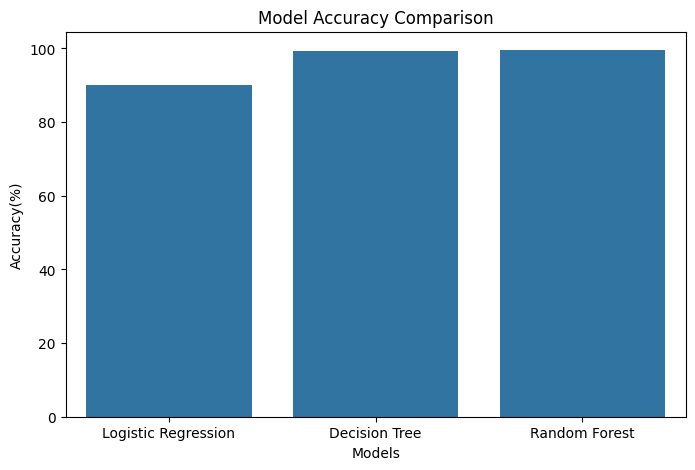

In [64]:
# Plot accuracy graph

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy(%)",
    data=model_comparison
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy(%)")

plt.show()

In [65]:
# Find the best model

best_model = model_comparison.loc[
    model_comparison["Accuracy(%)"].idxmax()
]

print(best_model)

Model          Random Forest
Accuracy(%)            99.55
Name: 2, dtype: object


In [66]:
# Selecting Random Forest as the final model

final_model = rf_model

In [67]:
# Creating confusion matrix

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

[[1613    0]
 [   9  378]]


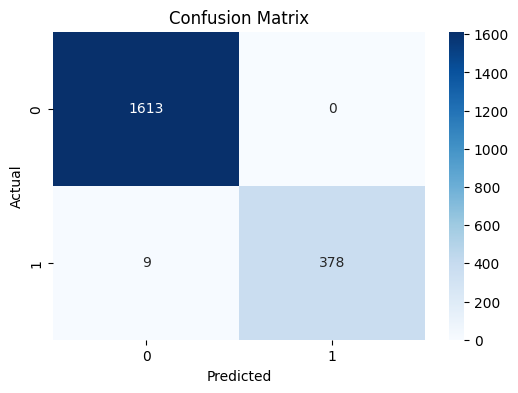

In [68]:
# Plotting confusion matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [69]:
# Display classification report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1613
           1       1.00      0.98      0.99       387

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [70]:
# Calculate feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
})

In [71]:
# Sort feature importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,River Discharge (m³/s),0.158113
2,Rainfall (mm),0.155103
6,Water Level (m),0.154793
4,Humidity (%),0.153283
7,Elevation (m),0.150024
11,Infrastructure,0.128757
1,Longitude,0.021728
3,Temperature (°C),0.021006
0,Latitude,0.020139
10,Population Density,0.019532


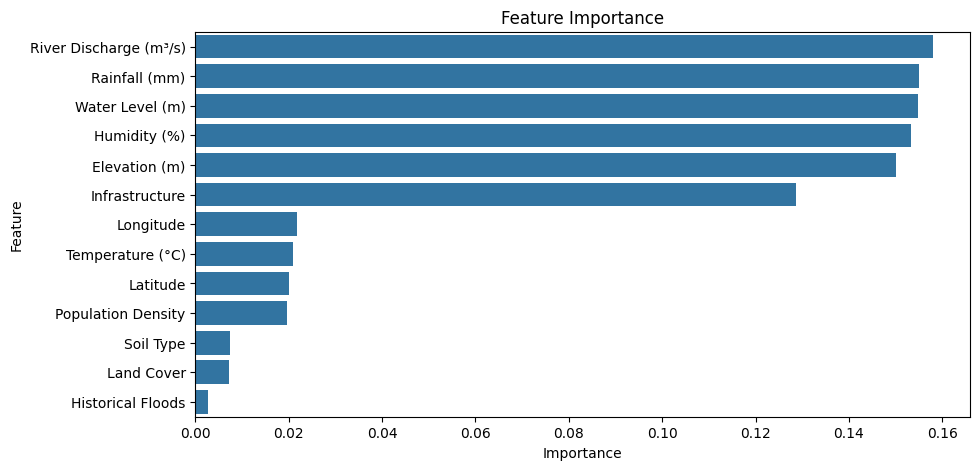

In [72]:
# Plot feature importance

plt.figure(figsize=(10,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

In [73]:
# Function for flood prediction

def predict_flood_risk(input_data):

    input_df = pd.DataFrame(
        [input_data],
        columns=X.columns
    )

    input_scaled = scaler.transform(input_df)

    prediction = final_model.predict(input_scaled)

    return prediction[0]

In [74]:
# Display feature names

print(X.columns)

Index(['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)',
       'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)',
       'Elevation (m)', 'Land Cover', 'Soil Type', 'Population Density',
       'Infrastructure', 'Historical Floods'],
      dtype='object')


In [75]:
# Predict new data

new_data = [
    22.57,      # Latitude
    88.36,      # Longitude
    250,        # Rainfall (mm)
    30,         # Temperature (°C)
    85,         # Humidity (%)
    500,        # River Discharge (m³/s)
    8,          # Water Level (m)
    10,         # Elevation (m)
    2,          # Land Cover
    1,          # Soil Type
    5000,       # Population Density
    1,          # Infrastructure
    3           # Historical Floods
 ]

In [76]:
# Predict flood risk

result = predict_flood_risk(new_data)

print("Prediction:", result)

Prediction: 1


In [77]:
# Display prediction result

if (result == 1):
    print("Flood Risk: HIGH")

else:
    print("Flood Risk: LOW")

Flood Risk: HIGH
